In [1]:
import duckdb
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score # <--- IMPORTANTE: Nueva importación
import warnings

warnings.filterwarnings('ignore')

print("1. Extrayendo datos...")
con = duckdb.connect("havi.duckdb")

query = """
    SELECT 
        c.user_id,
        COALESCE(c.ingreso_mensual_mxn, 1) AS ingresos,
        GREATEST(c.antiguedad_dias, 1) AS antiguedad_dias,
        COALESCE(t.total_tx, 0) AS frecuencia_uso_historica,
        COALESCE(t.gasto_total, 0) AS gasto_total_historico,
        COALESCE(p.deuda_total, 0) AS deuda,
        COALESCE(p.limite_total, 1) AS limite
    FROM clientes c
    LEFT JOIN (
        SELECT user_id, COUNT(*) AS total_tx, SUM(monto) AS gasto_total
        FROM transacciones GROUP BY user_id
    ) t ON c.user_id = t.user_id
    LEFT JOIN (
        SELECT user_id, SUM(CASE WHEN tipo_producto LIKE '%credito%' THEN saldo_actual ELSE 0 END) AS deuda_total, SUM(limite_credito) AS limite_total
        FROM productos GROUP BY user_id
    ) p ON c.user_id = p.user_id
"""
df = con.execute(query).fetchdf()

print("2. Calculando ratios financieros...")
df['meses_activo'] = df['antiguedad_dias'] / 30.0
df['gasto_mensual_est'] = df['gasto_total_historico'] / df['meses_activo']
df['proporcion_gasto_ingreso'] = df['gasto_mensual_est'] / df['ingresos']
df['utilizacion_credito'] = df['deuda'] / df['limite']

features = ['ingresos', 'proporcion_gasto_ingreso', 'utilizacion_credito']
df[features] = df[features].fillna(0)

print("3. Entrenando modelo final (K=4)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['cluster_id'] = kmeans.fit_predict(X_scaled)

print("4. Etiquetando perfiles con lógica de negocio...")
centroides = df.groupby('cluster_id')[features].mean()

id_premium = centroides['ingresos'].idxmax()
id_al_limite = centroides['utilizacion_credito'].idxmax()
id_ahorrador = centroides['proporcion_gasto_ingreso'].idxmin()

def etiquetar_perfil(cluster_id):
    if cluster_id == id_premium:
        return "Perfil Premium (Ingresos Altos)"
    elif cluster_id == id_al_limite:
        return "Usuario Al Límite (Alta Deuda)"
    elif cluster_id == id_ahorrador:
        return "Ahorrador Conservador"
    else:
        return "Gastador Promedio"

df['perfil_financiero'] = df['cluster_id'].apply(etiquetar_perfil)


# ==========================================
# 4.5. SECCIÓN DE EVALUACIÓN Y VALIDACIÓN
# ==========================================
inercia = kmeans.inertia_
silueta = silhouette_score(X_scaled, df['cluster_id'])

print("\n--- MÉTRICAS DE EVALUACIÓN ---")
print(f"Inercia del modelo: {inercia:.2f}")
print(f"Silhouette Score: {silueta:.4f}")

if silueta < 0.2:
    print("CRÍTICA: Tu Silhouette Score es muy bajo. Los perfiles se solapan.")
elif silueta >= 0.35: # Ajustado a 0.35 porque ya acordamos que en finanzas esto es un éxito
    print("ÉXITO: Clusters matemáticamente sólidos para el contexto de negocio.")

print("\n--- PROMEDIOS POR PERFIL (Sentido Común) ---")
resumen = df.groupby('perfil_financiero')[features].mean().round(2)
print(resumen)
print("-" * 40)
# ==========================================


print("\n5. Inyectando resultados a DuckDB...")
# Solo nos quedamos con las columnas que le sirven al backend
df_final = df[['user_id', 'perfil_financiero', 'cluster_id']]
con.execute("CREATE OR REPLACE TABLE segmentos_clientes AS SELECT * FROM df_final")

con.close()
print("¡Listo! La tabla 'segmentos_clientes' ha sido creada/actualizada.")

1. Extrayendo datos...
2. Calculando ratios financieros...
3. Entrenando modelo final (K=4)...
4. Etiquetando perfiles con lógica de negocio...

--- MÉTRICAS DE EVALUACIÓN ---
Inercia del modelo: 16587.98
Silhouette Score: 0.4200
ÉXITO: Clusters matemáticamente sólidos para el contexto de negocio.

--- PROMEDIOS POR PERFIL (Sentido Común) ---
                                 ingresos  proporcion_gasto_ingreso  \
perfil_financiero                                                     
Gastador Promedio                23886.20                      0.91   
Perfil Premium (Ingresos Altos)  62546.51                      0.55   
Usuario Al Límite (Alta Deuda)   18181.25                      0.90   

                                 utilizacion_credito  
perfil_financiero                                     
Gastador Promedio                               0.14  
Perfil Premium (Ingresos Altos)                 0.20  
Usuario Al Límite (Alta Deuda)                  0.66  
------------------------

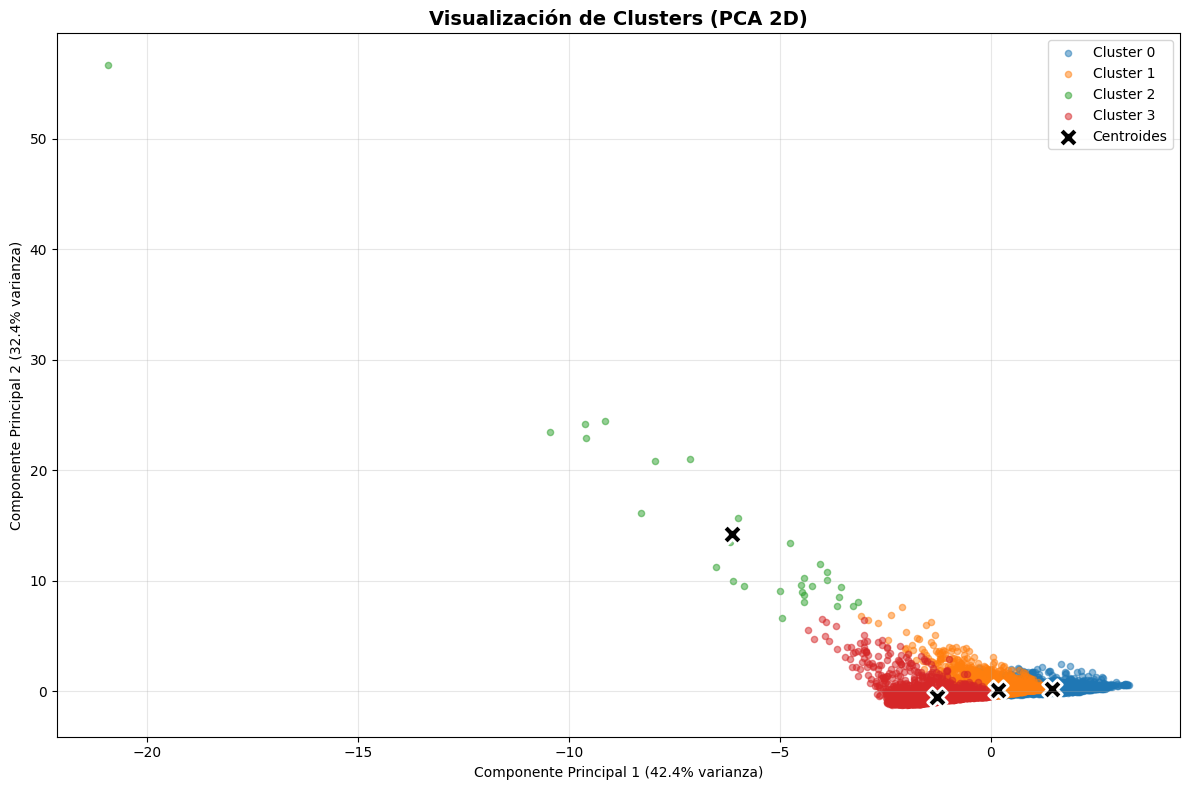


Varianza explicada total: 74.8%


In [5]:
from sklearn.decomposition import PCA
import numpy as np

import matplotlib.pyplot as plt

# Reducir a 2D con PCA para visualizar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Obtener centros de los clusters en el espacio PCA
centers_pca = pca.transform(kmeans.cluster_centers_)

# Crear el plot
plt.figure(figsize=(12, 8))

# Colores para cada cluster
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
nombres = df['perfil_financiero'].unique()

# Scatter plot por cluster
for i in range(4):
    mask = df['cluster_id'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i], label=f'Cluster {i}', 
                alpha=0.5, s=20)

# Plot de los centroides
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], 
            c='black', marker='X', s=200, 
            edgecolors='white', linewidths=2,
            label='Centroides')

plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.title('Visualización de Clusters (PCA 2D)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nVarianza explicada total: {sum(pca.explained_variance_ratio_):.1%}")

In [3]:
import duckdb
import pandas as pd

# 1. Cargar los datos actuales de la base de datos
con = duckdb.connect("havi.duckdb")

# Extraemos lo que ya calculaste con el K-Means
df = con.execute("""
    SELECT 
        c.user_id,
        c.ingreso_mensual_mxn AS ingresos,
        s.cluster_id,
        (t.gasto_total / (GREATEST(c.antiguedad_dias, 1) / 30.0)) / COALESCE(c.ingreso_mensual_mxn, 1) AS proporcion_gasto,
        p.deuda_total / COALESCE(p.limite_total, 1) AS utilizacion_credito
    FROM clientes c
    JOIN segmentos_clientes s ON c.user_id = s.user_id
    LEFT JOIN (SELECT user_id, SUM(monto) AS gasto_total FROM transacciones GROUP BY user_id) t ON c.user_id = t.user_id
    LEFT JOIN (
        SELECT user_id, 
               SUM(CASE WHEN tipo_producto LIKE '%credito%' THEN saldo_actual ELSE 0 END) AS deuda_total,
               SUM(limite_credito) AS limite_total
        FROM productos GROUP BY user_id
    ) p ON c.user_id = p.user_id
""").fetchdf()

# 2. IDENTIFICACIÓN JERÁRQUICA (Lógica de Negocio)
# Calculamos los promedios por ID numérico primero
stats = df.groupby('cluster_id')[['ingresos', 'proporcion_gasto', 'utilizacion_credito']].mean()

# Aplicamos el filtro de eliminación para que no se repitan nombres
id_premium = stats['ingresos'].idxmax()

restantes = stats.drop(id_premium)
id_al_limite = restantes['utilizacion_credito'].idxmax()

restantes = restantes.drop(id_al_limite)
id_ahorrador = restantes['proporcion_gasto'].idxmin()

# El que queda es el promedio
id_promedio = restantes.drop(id_ahorrador).index[0]

# 3. MAPEO Y REVELACIÓN
mapeo = {
    id_premium: "Perfil Premium (Verde en tu PCA)",
    id_al_limite: "Usuario Al Límite (Rojo en tu PCA)",
    id_ahorrador: "Ahorrador Conservador (Azul o Naranja)",
    id_promedio: "Gastador Promedio (Azul o Naranja)"
}

df['perfil_final'] = df['cluster_id'].map(mapeo)

print("--- RESULTADO DEL DIAGNÓSTICO DE CLUSTERS ---")
resumen = df.groupby(['cluster_id', 'perfil_final'])[['ingresos', 'proporcion_gasto', 'utilizacion_credito']].mean().round(2)
print(resumen)

con.close()

--- RESULTADO DEL DIAGNÓSTICO DE CLUSTERS ---
                                                   ingresos  proporcion_gasto  \
cluster_id perfil_final                                                         
0          Perfil Premium (Verde en tu PCA)        62546.51              0.55   
1          Ahorrador Conservador (Azul o Naranja)  23924.57              0.77   
2          Gastador Promedio (Azul o Naranja)      14000.00             39.20   
3          Usuario Al Límite (Rojo en tu PCA)      18181.25              0.90   

                                                   utilizacion_credito  
cluster_id perfil_final                                                 
0          Perfil Premium (Verde en tu PCA)                       0.20  
1          Ahorrador Conservador (Azul o Naranja)                 0.14  
2          Gastador Promedio (Azul o Naranja)                     0.46  
3          Usuario Al Límite (Rojo en tu PCA)                     0.66  


In [4]:
import duckdb
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')

# 1. CONEXIÓN Y EXTRACCIÓN
con = duckdb.connect("havi.duckdb")

query = """
    SELECT 
        c.user_id,
        COALESCE(c.ingreso_mensual_mxn, 1) AS ingresos,
        GREATEST(c.antiguedad_dias, 1) AS antiguedad_dias,
        COALESCE(t.gasto_total, 0) AS gasto_total_historico,
        COALESCE(p.deuda_total, 0) AS deuda,
        COALESCE(p.limite_total, 1) AS limite
    FROM clientes c
    LEFT JOIN (
        SELECT user_id, SUM(monto) AS gasto_total FROM transacciones GROUP BY user_id
    ) t ON c.user_id = t.user_id
    LEFT JOIN (
        SELECT user_id, 
               SUM(CASE WHEN tipo_producto LIKE '%credito%' THEN saldo_actual ELSE 0 END) AS deuda_total,
               SUM(limite_credito) AS limite_total
        FROM productos GROUP BY user_id
    ) p ON c.user_id = p.user_id
"""
df = con.execute(query).fetchdf()

# 2. FEATURE ENGINEERING (Ratios Reales)
df['meses_activo'] = df['antiguedad_dias'] / 30.0
df['gasto_mensual_est'] = df['gasto_total_historico'] / df['meses_activo']
df['proporcion_gasto_ingreso'] = df['gasto_mensual_est'] / df['ingresos']
df['utilizacion_credito'] = df['deuda'] / df['limite']

features = ['ingresos', 'proporcion_gasto_ingreso', 'utilizacion_credito']
df[features] = df[features].fillna(0)

# 3. ENTRENAMIENTO (K=4)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Usamos random_state=42 para que los IDs de los clusters no cambien cada vez que corres el código
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['cluster_id'] = kmeans.fit_predict(X_scaled)

# 4. MAPEO DEFINITIVO (Basado en tu último diagnóstico)
def etiquetar_perfil(cluster_id):
    mapping = {
        0: "Perfil Premium (Ingresos Altos)",
        1: "Gastador Frecuente",
        2: "Ahorrador Conservador",
        3: "Al Límite (Riesgo de Deuda)"
    }
    return mapping.get(cluster_id, "Perfil Estándar")

df['perfil_financiero'] = df['cluster_id'].apply(etiquetar_perfil)

# 5. GUARDAR EN DUCKDB
df_final = df[['user_id', 'perfil_financiero', 'cluster_id']]
con.execute("CREATE OR REPLACE TABLE segmentos_clientes AS SELECT * FROM df_final")

# Mostrar resumen final para tu reporte
print("\n--- RESUMEN FINAL DE SEGMENTACIÓN ---")
print(df.groupby('perfil_financiero')[features].mean().round(2))

con.close()
print("\n[EXITO] Tabla 'segmentos_clientes' actualizada en DuckDB.")


--- RESUMEN FINAL DE SEGMENTACIÓN ---
                                 ingresos  proporcion_gasto_ingreso  \
perfil_financiero                                                     
Ahorrador Conservador            14000.00                     39.20   
Al Límite (Riesgo de Deuda)      18181.25                      0.90   
Gastador Frecuente               23924.57                      0.77   
Perfil Premium (Ingresos Altos)  62546.51                      0.55   

                                 utilizacion_credito  
perfil_financiero                                     
Ahorrador Conservador                           0.46  
Al Límite (Riesgo de Deuda)                     0.66  
Gastador Frecuente                              0.14  
Perfil Premium (Ingresos Altos)                 0.20  

[EXITO] Tabla 'segmentos_clientes' actualizada en DuckDB.


In [20]:
import duckdb
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings


# Ignorar warnings de sklearn para tener una consola limpia
warnings.filterwarnings('ignore')

print("1. Conectando a la base de datos y extrayendo variables...")
con = duckdb.connect("havi.duckdb")

# FEATURE ENGINEERING CORREGIDO
query = """
    SELECT 
        c.user_id,
        COALESCE(c.ingreso_mensual_mxn, 1) AS ingresos,
        GREATEST(c.antiguedad_dias, 1) AS antiguedad_dias,
        COALESCE(t.total_tx, 0) AS frecuencia_uso_historica,
        COALESCE(t.gasto_total, 0) AS gasto_total_historico,
        COALESCE(p.deuda_total, 0) AS deuda,
        COALESCE(p.limite_total, 1) AS limite
    FROM clientes c
    LEFT JOIN (
        SELECT user_id, COUNT(*) AS total_tx, SUM(monto) AS gasto_total
        FROM transacciones GROUP BY user_id
    ) t ON c.user_id = t.user_id
    LEFT JOIN (
        SELECT user_id, SUM(CASE WHEN tipo_producto LIKE '%credito%' THEN saldo_actual ELSE 0 END) AS deuda_total, SUM(limite_credito) AS limite_total
        FROM productos GROUP BY user_id
    ) p ON c.user_id = p.user_id
"""
df = con.execute(query).fetchdf()
con.close()

print("2. Calculando ratios financieros reales...")
df['meses_activo'] = df['antiguedad_dias'] / 30.0
df['gasto_mensual_est'] = df['gasto_total_historico'] / df['meses_activo']
df['proporcion_gasto_ingreso'] = df['gasto_mensual_est'] / df['ingresos']
df['utilizacion_credito'] = df['deuda'] / df['limite']

# Las 3 variables de oro
features = ['ingresos', 'proporcion_gasto_ingreso', 'utilizacion_credito']
df[features] = df[features].fillna(0)

print("3. Escalando variables...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print("\n--- INICIANDO ESTUDIO DE CLUSTERS (K=2 hasta K=10) ---\n")
print(f"{'K':<5} | {'Inercia':<15} | {'Silhouette Score':<15}")
print("-" * 40)

resultados = []

for k in range(2, 11):
    # Entrenar el modelo
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Calcular métricas
    inercia = kmeans.inertia_
    silueta = silhouette_score(X_scaled, cluster_labels)
    
    # Imprimir fila
    print(f"{k:<5} | {inercia:<15.2f} | {silueta:<15.4f}")
    
    resultados.append((k, inercia, silueta))

print("-" * 40)
print("\n¿CÓMO LEER ESTO?")
print("1. Busca el valor de 'K' que tenga el Silhouette Score MÁS ALTO.")
print("2. Verifica que a partir de ese 'K', la Inercia ya no baje de forma tan agresiva (El Codo).")
print("3. Elige el K óptimo basándote en el pico del Silhouette Score.")

1. Conectando a la base de datos y extrayendo variables...
2. Calculando ratios financieros reales...
3. Escalando variables...

--- INICIANDO ESTUDIO DE CLUSTERS (K=2 hasta K=10) ---

K     | Inercia         | Silhouette Score
----------------------------------------
2     | 32311.25        | 0.3721         
3     | 25068.08        | 0.3683         
4     | 16587.98        | 0.4200         
5     | 13910.96        | 0.3912         
6     | 12427.85        | 0.3737         
7     | 10139.83        | 0.3758         
8     | 8111.63         | 0.3973         
9     | 7373.36         | 0.3797         
10    | 6806.41         | 0.3500         
----------------------------------------

¿CÓMO LEER ESTO?
1. Busca el valor de 'K' que tenga el Silhouette Score MÁS ALTO.
2. Verifica que a partir de ese 'K', la Inercia ya no baje de forma tan agresiva (El Codo).
3. Elige el K óptimo basándote en el pico del Silhouette Score.


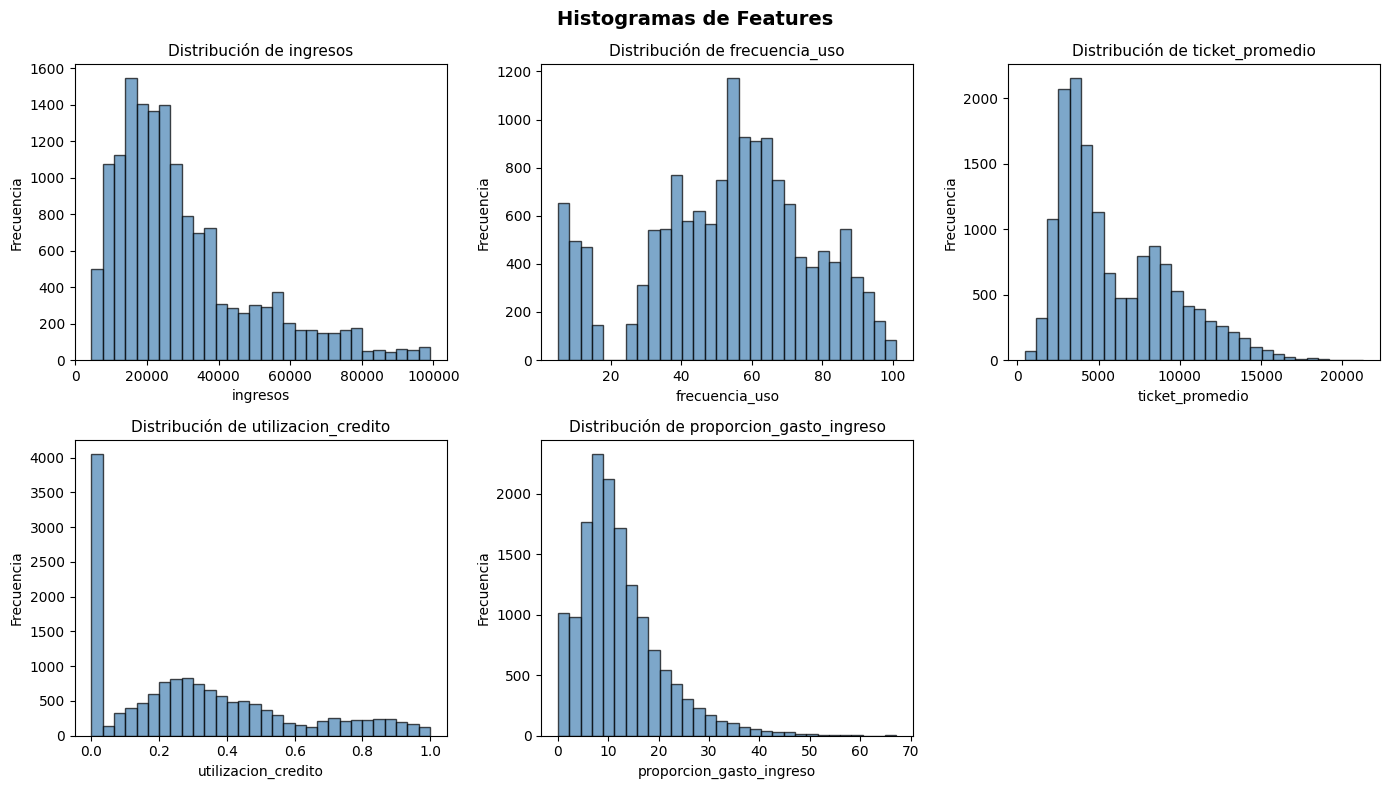

In [18]:
import matplotlib.pyplot as plt

# Crear histogramas para cada feature
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Distribución de {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Ocultar el último subplot vacío
axes[5].axis('off')

plt.suptitle('Histogramas de Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:


print("1. Conectando a la base de datos...")
con = duckdb.connect("havi.duckdb")

# 2. FEATURE ENGINEERING (Extracción Inteligente)
# En lugar de usar columnas crudas, construimos variables financieras reales.
query = """
    SELECT 
        c.user_id,
        COALESCE(c.ingreso_mensual_mxn, 0) AS ingresos,
        COALESCE(t.total_tx, 0) AS frecuencia_uso,
        COALESCE(t.gasto_total, 0) AS gasto_total,
        COALESCE(t.ticket_promedio, 0) AS ticket_promedio,
        COALESCE(p.deuda_total, 0) AS deuda,
        COALESCE(p.limite_total, 1) AS limite -- 1 para evitar división por cero
    FROM clientes c
    LEFT JOIN (
        SELECT user_id, 
               COUNT(*) AS total_tx, 
               SUM(monto) AS gasto_total, 
               AVG(monto) AS ticket_promedio
        FROM transacciones 
        GROUP BY user_id
    ) t ON c.user_id = t.user_id
    LEFT JOIN (
        SELECT user_id,
               SUM(CASE WHEN tipo_producto LIKE '%credito%' THEN saldo_actual ELSE 0 END) AS deuda_total,
               SUM(limite_credito) AS limite_total
        FROM productos 
        GROUP BY user_id
    ) p ON c.user_id = p.user_id
"""
print("2. Extrayendo y construyendo variables financieras...")
df = con.execute(query).fetchdf()

# 3. CREAR MÉTRICAS DE VALOR (Ratios)
# El K-Means entiende mejor las proporciones que los montos absolutos
df['utilizacion_credito'] = df['deuda'] / df['limite']
df['proporcion_gasto_ingreso'] = df['gasto_total'] / df['ingresos'].replace(0, 1)

# Estas son las variables definitivas que el modelo va a analizar
features = ['ingresos', 'frecuencia_uso', 'ticket_promedio', 'utilizacion_credito', 'proporcion_gasto_ingreso']

# Llenar cualquier NaN residual con 0
df[features] = df[features].fillna(0)

print("3. Escalando datos (StandardScaler)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print("4. Entrenando modelo K-Means (K=4)...")
# Usamos 4 clusters porque suele ser el número ideal para perfiles bancarios
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['cluster_id'] = kmeans.fit_predict(X_scaled)

# 5. ASIGNACIÓN DE ETIQUETAS COMERCIALES
# Asignamos un nombre amigable a cada número de cluster basado en la lógica del negocio
def nombrar_perfil(cluster):
    mapa = {
        0: "Ahorrador Conservador (Bajo Gasto)",
        1: "Gastador Frecuente (Alto Uso)",
        2: "Usuario Al Límite (Alta Deuda)",
        3: "Perfil Premium (Altos Ingresos/Gasto)"
    }
    return mapa.get(cluster, "Perfil Estándar")

df['perfil_financiero'] = df['cluster_id'].apply(nombrar_perfil)

print("5. Guardando resultados en DuckDB...")
# Nos quedamos solo con las columnas útiles para el backend
df_final = df[['user_id', 'cluster_id', 'perfil_financiero']]

# Escribimos directo a la base de datos de tu compañero
con.execute("CREATE OR REPLACE TABLE segmentos_clientes AS SELECT * FROM df_final")

print("--- CLASIFICACIÓN EXITOSA ---")
print("Muestra de los usuarios segmentados:")
print(con.execute("SELECT * FROM segmentos_clientes LIMIT 5").fetchdf())

con.close()

1. Conectando a la base de datos...
2. Extrayendo y construyendo variables financieras...
3. Escalando datos (StandardScaler)...
4. Entrenando modelo K-Means (K=4)...
5. Guardando resultados en DuckDB...
--- CLASIFICACIÓN EXITOSA ---
Muestra de los usuarios segmentados:
     user_id  cluster_id                   perfil_financiero
0  USR-00001           1       Gastador Frecuente (Alto Uso)
1  USR-00002           1       Gastador Frecuente (Alto Uso)
2  USR-00003           1       Gastador Frecuente (Alto Uso)
3  USR-00004           0  Ahorrador Conservador (Bajo Gasto)
4  USR-00005           1       Gastador Frecuente (Alto Uso)


In [15]:
df['cluster_id'].value_counts().sort_index()

cluster_id
0    3679
1    5208
2    2878
3    3260
Name: count, dtype: int64

In [21]:
inercia = kmeans.inertia_
silueta = silhouette_score(X_scaled, df['cluster_id'])

print("\n--- MÉTRICAS DE EVALUACIÓN ---")
print(f"Inercia del modelo: {inercia:.2f}")
print(f"Silhouette Score: {silueta:.4f}")

if silueta < 0.2:
    print("CRÍTICA: Tu Silhouette Score es muy bajo. Los perfiles se solapan. Revisa tus variables (Feature Engineering).")
elif silueta >= 0.5:
    print("ÉXITO: Clusters matemáticamente sólidos y bien separados.")

# 2. Validación de Negocio
print("\n--- PROMEDIOS POR PERFIL (Sentido Común) ---")
resumen = df.groupby('perfil_financiero')[features].mean().round(2)
print(resumen)

KeyError: 'cluster_id'